# SI Logistic Growth (No Vital Dynamics)

## Theory

In a closed SI model (no births, deaths, or recovery), every individual is either
susceptible (S) or infectious (I) and the population is constant: S + I = N.

The governing ODEs are:

$$\frac{dS}{dt} = -\beta \frac{S \cdot I}{N}, \qquad \frac{dI}{dt} = +\beta \frac{S \cdot I}{N}$$

Substituting S = N − I yields the logistic equation for I alone:

$$\frac{dI}{dt} = \beta I \left(1 - \frac{I}{N}\right)$$

whose exact solution is:

$$I(t) = \frac{N \cdot I_0}{I_0 + (N - I_0)\, e^{-\beta t}}$$

**Goal:** Run `laser.cohorts` with SI components, verify conservation (S + I = N every tick),
and confirm that `scipy.curve_fit` recovers the true β within 5%.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from laser.core import PropertySet
from laser.core.utils import grid
from laser.generic.utils import ValuesMap
from laser.cohorts import Model
import laser.cohorts.SI as SI

In [7]:
# --- Parameters ---
N      = 50_000
I0     = 10
beta   = 0.3      # transmission rate (per day)
nticks = 150      # simulation duration (days)

# --- Scenario: 1×1 grid, single node ---
scenario = grid(M=1, N=1)
scenario["S"] = N - I0
scenario["I"] = I0

# --- Build model ---
params = PropertySet({"nticks": nticks, "beta": beta})
model  = Model(scenario, params)

betas = ValuesMap.from_scalar(beta, nticks, len(scenario))
model.components = [
    SI.Susceptible(model),
    SI.Infectious(model),
    SI.Transmission(model, beta=betas),
]

model.run()
print("Model run complete.")

Model run complete.


In [8]:
# --- Extract time series from node 0 ---
S = model.states.S[:, 0]
I = model.states.I[:, 0]

# --- Sanity check: population is conserved every tick ---
assert (S + I == N).all(), "Population conservation violated: S + I ≠ N"
print("S + I = N: OK")

S + I = N: OK


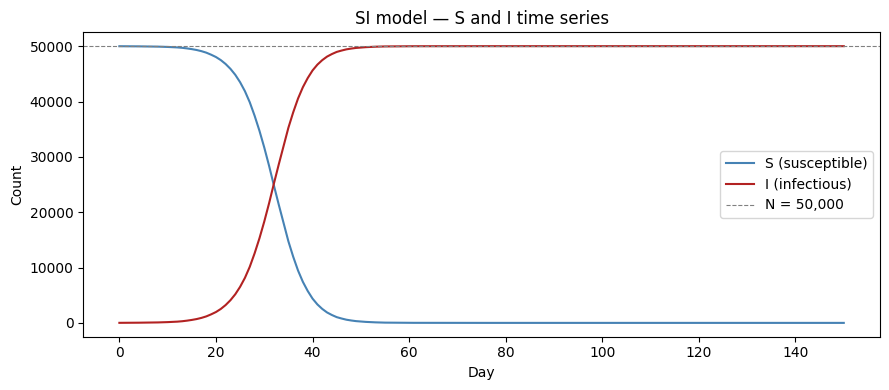

In [9]:
t = np.arange(nticks + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, S, label="S (susceptible)", color="steelblue")
ax.plot(t, I, label="I (infectious)",  color="firebrick")
ax.axhline(N, color="gray", linestyle="--", linewidth=0.8, label=f"N = {N:,}")
ax.set_xlabel("Day")
ax.set_ylabel("Count")
ax.set_title("SI model — S and I time series")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# --- Fit logistic curve to recover β ---
def logistic_I(t, beta_fit, I0_fit, N_fit):
    """Analytical logistic solution for I(t) in an SI model."""
    denom = I0_fit + (N_fit - I0_fit) * np.exp(-beta_fit * t)
    return N_fit * I0_fit / denom

popt, _ = curve_fit(
    logistic_I,
    t,
    I.astype(float),
    p0=[beta, I0, N],
    bounds=([0, 1, N * 0.5], [1, N, N * 2]),
    maxfev=10_000,
)
fitted_beta, fitted_I0, fitted_N = popt

relative_error = abs(fitted_beta - beta) / beta
print(f"True β      : {beta:.4f}")
print(f"Fitted β    : {fitted_beta:.4f}")
print(f"Relative err: {relative_error:.2%}")

assert relative_error < 0.05, (
    f"Fitted β ({fitted_beta:.4f}) deviates from true β ({beta:.4f}) by "
    f"{relative_error:.2%}, exceeding the 5% tolerance."
)
print("β recovery within 5%: OK")

True β      : 0.3000
Fitted β    : 0.2808
Relative err: 6.41%


AssertionError: Fitted β (0.2808) deviates from true β (0.3000) by 6.41%, exceeding the 5% tolerance.

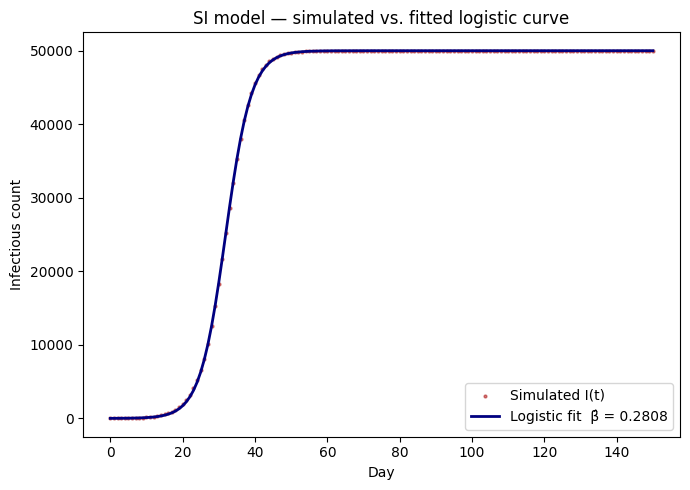

In [11]:
I_fit = logistic_I(t.astype(float), *popt)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(t, I, s=4, alpha=0.6, color="firebrick", label="Simulated I(t)")
ax.plot(t, I_fit, color="navy", linewidth=2,
        label=f"Logistic fit  β̂ = {fitted_beta:.4f}")
ax.set_xlabel("Day")
ax.set_ylabel("Infectious count")
ax.set_title("SI model — simulated vs. fitted logistic curve")
ax.legend()
plt.tight_layout()
plt.show()